Copyright (c) MONAI Consortium  
Licensed under the Apache License, Version 2.0 (the "License");  
you may not use this file except in compliance with the License.  
You may obtain a copy of the License at  
&nbsp;&nbsp;&nbsp;&nbsp;http://www.apache.org/licenses/LICENSE-2.0  
Unless required by applicable law or agreed to in writing, software  
distributed under the License is distributed on an "AS IS" BASIS,  
WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.  
See the License for the specific language governing permissions and  
limitations under the License.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ImagingDataCommons/idc-monai/blob/main/monai_contribution/idc_dataset.ipynb)

# Using NCI Imaging Data Commons with MONAI

## What is IDC?

[NCI Imaging Data Commons (IDC)](https://portal.imaging.datacommons.cancer.gov/) is a free, cloud-hosted repository of publicly available cancer imaging data maintained by the National Cancer Institute (NCI). It provides:

- **~100 TB** of radiology (CT, MR, PET) and pathology images across 160+ cancer collections
- **No sign-up or authentication required** — data is openly accessible
- **Expert and AI-generated annotations** (e.g., organ segmentations) paired with images
- **Standardized format** — all data uses DICOM, the medical imaging industry standard
- **Cloud-native storage** — data lives in Google Cloud Storage (GCS) buckets, so downloads are fast
- **Accompanying tools** - you can search, visualize, and subset the data

## What is `idc-index`?

[`idc-index`](https://github.com/ImagingDataCommons/idc-index) is a lightweight Python package that lets you search and download IDC data without any cloud account or special credentials. It ships with a local metadata index — a set of DuckDB tables describing every image series in IDC — so you can run SQL queries locally to find exactly the data you need before downloading anything.

## What this tutorial covers

This tutorial shows how to:
1. Query IDC metadata with SQL to find cancer imaging data
2. Download DICOM images and segmentations with one function call
3. Load the data into MONAI for AI/ML preprocessing
4. Work with DICOM Segmentation (DICOM-SEG) objects and their rich metadata

> **Tip**: This tutorial was created using [idc-claude-skill](https://github.com/ImagingDataCommons/idc-claude-skill) — an AI assistant skill for navigating IDC data and the `idc-index` API.

## Setup environment

Install required packages:
- `monai` — Medical Open Network for AI, the ML framework used here
- `idc-index` — Query and download IDC data (includes local metadata index)
- `itk` / `itkwasm-dicom` — ITK-based DICOM readers used by MONAI's `ITKReader` and our custom DICOM-SEG loader

> **Colab users**: After running the cell below, restart the runtime before continuing (Runtime → Restart runtime). ITK requires a fresh runtime to load correctly after installation.

In [ ]:
!pip install -q monai idc-index itk itkwasm-dicom

## Setup imports

In [ ]:
import os
import sys
import tempfile
from pathlib import Path
from typing import Hashable, Mapping

import itkwasm_dicom
import matplotlib.pyplot as plt
import numpy as np
import torch
from idc_index import IDCClient
from matplotlib.colors import ListedColormap

import monai
from monai.config import KeysCollection
from monai.data import Dataset, MetaTensor
from monai.data.image_reader import ITKReader
from monai.transforms import (
    Compose,
    EnsureChannelFirstd,
    LoadImaged,
    MapTransform,
    Orientationd,
    ScaleIntensityRanged,
    Spacingd,
)

monai.config.print_config()

## 1. Discover Data with `idc-index`

`idc-index` ships with a built-in local metadata index — a DuckDB database containing one row per DICOM series in IDC. You query it using standard SQL via `client.sql_query()`. **No internet connection is needed for queries** — only for downloading actual image files, or for installing optional components of `idc-index`.

The primary table is `index`, which has one row per DICOM series and includes columns like:
- `SeriesInstanceUID` — unique identifier for a series (used for downloading)
- `collection_id` — which dataset the series belongs to (e.g., `lidc_idri`, `nlst`)
- `PatientID`, `StudyInstanceUID` — standard DICOM identifiers
- `Modality` — imaging type (`CT`, `MR`, `SEG`, `RTSTRUCT`, etc.)
- `series_size_MB` — download size in megabytes
- `license_short_name` — data license (important before use in a project)

Additional index tables (loaded on demand with `fetch_index()`) extend this with collection-level info, segmentation metadata, volume geometry, metadata specific to pathology images, etc (see [this documentation page](https://idc-index.readthedocs.io/en/latest/indices_reference.html) for details).

In [ ]:
# IDCClient is the main entry point for idc-index.
client = IDCClient()

# IDC releases versioned snapshots of the metadata.
# The version number tells you which data release the local index reflects.
print(f"IDC version: {client.get_idc_version()}")

# Query the primary 'index' table to see the overall scale of IDC.
# 'collection_id' groups series by dataset; 'PatientID' is the DICOM patient identifier.
stats = client.sql_query(
    """
    SELECT COUNT(DISTINCT collection_id) as collections,
           COUNT(DISTINCT PatientID) as patients,
           COUNT(DISTINCT SeriesInstanceUID) as series,
           SUM(series_size_MB) as size_mb,
           ROUND(SUM(series_size_MB) / 1e6, 2) as size_tb
    FROM index
"""
)
row = stats.iloc[0]
print(f"Collections: {row['collections']}, Patients: {row['patients']}, Total size: {row['size_tb']}TB")

In [ ]:
# 'collections_index' is an optional table with one row per IDC collection.
# It adds collection-level metadata not in the per-series 'index' t able,
# such as CancerTypes, Subjects count, and collection descriptions.
client.fetch_index("collections_index")

# Join collections_index with the per-series index to filter by both cancer type and modality.
# The 'index' table has Modality per series; collections_index has CancerTypes per collection.
lung_collections = client.sql_query(
    """
    SELECT c.collection_id, c.Subjects, c.CancerTypes,
           COUNT(DISTINCT CASE WHEN i.Modality = 'CT' THEN i.SeriesInstanceUID END) as ct_series
    FROM collections_index c
    JOIN index i ON c.collection_id = i.collection_id
    WHERE c.CancerTypes LIKE '%Lung%'
    GROUP BY c.collection_id, c.Subjects, c.CancerTypes
    HAVING ct_series > 0
    ORDER BY c.Subjects DESC
    LIMIT 5
"""
)
print("Lung CT collections:")
print(lung_collections.to_string(index=False))

Lung CT collections:
             collection_id  Subjects                                                                                                                                                                                                      CancerTypes  ct_series
                      nlst     26410                                                                                                                                                                                          Lung Cancer, Non-Cancer     203087
                 lidc_idri      1010                                                                                                                                                                      Lung Cancer, Non-Cancer, Metastatic disease       1018
                 tcga_luad       560                                                                                                                                                                            

In [ ]:
# 'volume_geometry_index' is a supplemental table that adds pre-computed
# geometric quality flags for each CT/MR series — for example:
#   regularly_spaced_3d_volume = TRUE means the slices form a clean 3D volume
#   (uniform spacing, no gaps, no duplicate positions).
# Filtering on this flag avoids downloading series that won't load cleanly into MONAI.
client.fetch_index("volume_geometry_index")

# Select a few small CT series that form well-formed 3D volumes.
# We join 'index' (series metadata) with 'volume_geometry_index' (geometry flags).
# ORDER BY series_size_MB is not here, but LIMIT 3 keeps the demo download small.
series_df = client.sql_query(
    """
    SELECT index.SeriesInstanceUID, PatientID, Modality,
           ROUND(series_size_MB, 2) as size_mb
    FROM index
    JOIN volume_geometry_index USING (SeriesInstanceUID)
    WHERE regularly_spaced_3d_volume = TRUE AND Modality = 'CT'
    LIMIT 3
"""
)
print(f"Found {len(series_df)} CT series")

Found 3 CT series


## 2. Download DICOM Data

`download_from_selection()` fetches DICOM files directly from IDC's Google Cloud Storage buckets. No account or credentials are needed — all IDC data is publicly accessible.

Files are organized on disk according to the `dirTemplate` pattern. Using `%SeriesInstanceUID` creates one subdirectory per series, which is what MONAI's `ITKReader` expects when loading a DICOM series.

In [45]:
# Create a temporary directory to hold downloaded DICOM files.
data_dir = tempfile.mkdtemp(prefix="idc_monai_")
series_uids = list(series_df["SeriesInstanceUID"])

print(f"Downloading {len(series_uids)} series...")
# download_from_selection() accepts a list of SeriesInstanceUIDs and fetches
# all DICOM files for those series from IDC's GCS buckets.
# dirTemplate="%SeriesInstanceUID" puts each series in its own subdirectory —
# required because MONAI's ITKReader reads a directory to reconstruct a 3D volume.
client.download_from_selection(seriesInstanceUID=series_uids, downloadDir=data_dir, dirTemplate="%SeriesInstanceUID")
print("Done!")

Done!


## 3. Load with MONAI Transforms

MONAI's `LoadImaged` with `ITKReader` directly loads DICOM series from directories.

In [46]:
# Define transforms for CT preprocessing
# Use ITKReader explicitly to load DICOM series from directories
transforms = Compose(
    [
        LoadImaged(keys=["image"], reader=ITKReader()),
        EnsureChannelFirstd(keys=["image"]),
        Orientationd(keys=["image"], axcodes="RAS"),
        Spacingd(keys=["image"], pixdim=(1.5, 1.5, 2.0)),
        ScaleIntensityRanged(keys=["image"], a_min=-175, a_max=250, b_min=0.0, b_max=1.0, clip=True),
    ]
)

# Create dataset
data_dicts = [{"image": os.path.join(data_dir, uid)} for uid in series_uids]
dataset = Dataset(data=data_dicts, transform=transforms)

# Load sample
sample = dataset[0]
print(f"Image shape: {sample['image'].shape}")
print(f"Value range: [{sample['image'].min():.2f}, {sample['image'].max():.2f}]")

monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.


Image shape: torch.Size([1, 280, 280, 171])
Value range: [0.00, 1.00]


## 4. Visualize

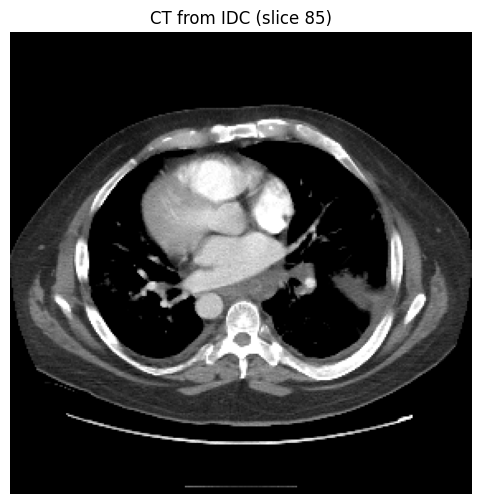

In [47]:
image = sample["image"][0]
z = image.shape[2] // 2

plt.figure(figsize=(6, 6))
plt.imshow(image[:, :, z].T, cmap="gray", origin="lower")
plt.title(f"CT from IDC (slice {z})")
plt.axis("off")
plt.show()

## 5. Loading DICOM Segmentations

IDC contains DICOM Segmentation (DICOM-SEG) objects. These are different from regular DICOM series:
- **Enhanced multiframe**: All slices in a single file
- **Cannot use ITKReader**: Standard readers don't support this format
- **Segment metadata**: Each segment has label, description, and recommended display color

We define a custom `LoadDicomSegd` transform that:
1. Uses `itkwasm-dicom` (wraps dcmqi) for robust DICOM-SEG reading
2. Derives the affine matrix directly from DICOM metadata (direction cosines, spacing, origin) — no axis flipping
3. Orientation is fully encoded in the affine via the direction cosine matrix
4. Extracts segment colors from DICOM metadata for visualization

> **Note**: CT and SEG may have different affines when acquired with different orientations (common with AI-generated segmentations like TotalSegmentator). Apply `Orientationd` to normalize both to a common orientation before voxel-level overlay.

In [48]:
# 'seg_index' is a supplemental index table with one row per DICOM Segmentation series in IDC.
# It adds metadata specific to segmentations that isn't in the primary 'index' table:
#   segmented_SeriesInstanceUID — the SeriesInstanceUID of the CT/MR image that was segmented
#   AlgorithmName              — the tool that created the segmentation (e.g., TotalSegmentator)
#   total_segments             — how many anatomical structures are labeled in the file
# fetch_index() downloads and caches it locally; once cached it won't re-download.
client.fetch_index("seg_index")

# Find CT series that have TotalSegmentator segmentations.
# TotalSegmentator is an AI model that auto-segments 100+ anatomical structures.
# The JOIN links each segmentation back to its source CT via segmented_SeriesInstanceUID.
# We sort by image size (ASC) so the demo downloads the smallest available pair.
paired = client.sql_query(
    """
    SELECT src.SeriesInstanceUID as image_uid,
           seg.SeriesInstanceUID as seg_uid,
           src.collection_id, seg.total_segments,
           ROUND(src.series_size_MB, 2) as image_mb
    FROM seg_index seg
    JOIN index src ON seg.segmented_SeriesInstanceUID = src.SeriesInstanceUID
    WHERE src.Modality = 'CT'
      AND seg.AlgorithmName LIKE '%TotalSegmentator%'
    ORDER BY src.series_size_MB ASC
    LIMIT 3
"""
)
print("CT with TotalSegmentator segmentations:")
print(paired.to_string(index=False))

CT with TotalSegmentator segmentations:
                                                  image_uid                                                   seg_uid collection_id  total_segments  image_mb
 1.2.840.113654.2.55.39501032054040159252741883490811009228 1.2.276.0.7230010.3.1.3.313263360.23926.1706319815.161829          nlst              47     26.32
1.2.840.113654.2.55.134877680474542655199243531560181528016 1.2.276.0.7230010.3.1.3.313263360.31910.1706312185.595733          nlst              73     26.32
1.2.840.113654.2.55.296129646159215067393462057349853219678 1.2.276.0.7230010.3.1.3.313263360.35421.1706312631.378111          nlst              62     26.32


In [ ]:
# Download one image-segmentation pair
demo_pair = paired.iloc[0]
seg_dir = tempfile.mkdtemp(prefix="idc_seg_")

print("Downloading image and segmentation pair...")
client.download_from_selection(
    seriesInstanceUID=[demo_pair["image_uid"], demo_pair["seg_uid"]],
    downloadDir=seg_dir,
    dirTemplate="%SeriesInstanceUID",
)
print("Done!")

In [ ]:
class LoadDicomSegd(MapTransform):
    """Load DICOM Segmentation (DICOM-SEG) files using ITKWasm.

    DICOM-SEG is an enhanced multiframe DICOM format that stores segmentation
    masks with segment metadata including recommended display colors.

    The affine matrix is derived directly from DICOM metadata (direction cosines,
    spacing, origin) with LPS→RAS conversion applied to match MONAI's ITKReader
    convention. No axis flipping is performed — orientation is fully encoded in
    the affine via the direction cosine matrix.
    """

    def __init__(self, keys: KeysCollection, allow_missing_keys: bool = False):
        super().__init__(keys, allow_missing_keys)

    def _find_dcm_file(self, path: Path) -> Path:
        """Find .dcm file in directory or return path if already a file."""
        if path.is_file():
            return path
        dcm_files = list(path.glob("*.dcm"))
        if not dcm_files:
            raise FileNotFoundError(f"No .dcm files found in {path}")
        return dcm_files[0]

    def _build_affine(self, spacing, origin, direction) -> np.ndarray:
        """Build 4x4 affine matrix from DICOM spatial metadata.

        Converts from ITK/DICOM LPS convention to MONAI's RAS-like convention
        by negating X and Y world coordinates (LPS→RAS). No axis flips are
        applied — orientation is fully encoded in the affine via the direction
        cosine matrix.

        Args:
            spacing:   Voxel spacing (X, Y, Z) as returned by itkwasm
            origin:    Physical coordinates of voxel [0,0,0] in LPS
            direction: 3x3 direction cosine matrix D where D[i,j] is the
                       component of voxel-axis-j's unit vector along LPS
                       physical axis i. ITK affine formula:
                       world_lps = D @ diag(spacing) @ voxel + origin
        """
        lps_to_ras = np.diag([-1.0, -1.0, 1.0])
        affine = np.eye(4)
        affine[:3, :3] = lps_to_ras @ direction @ np.diag(spacing)
        affine[:3, 3] = lps_to_ras @ origin
        return affine

    def __call__(self, data: Mapping[Hashable, any]) -> dict[Hashable, any]:
        d = dict(data)
        for key in self.key_iterator(d):
            path = Path(d[key])
            dcm_file = self._find_dcm_file(path)

            # Read using ITKWasm
            seg_image, overlay_info = itkwasm_dicom.read_segmentation(dcm_file)

            # ITKWasm returns array in (Z, Y, X) order but metadata in (X, Y, Z) order.
            # Transpose to (X, Y, Z) to match metadata — this is a layout convention,
            # not an orientation flip.
            seg_array = np.asarray(seg_image.data).copy()
            seg_array = np.transpose(seg_array, (2, 1, 0))

            # Build affine from spatial metadata
            spacing = np.array(seg_image.spacing)
            origin = np.array(seg_image.origin)
            direction = np.array(seg_image.direction).reshape(3, 3)

            affine = self._build_affine(spacing, origin, direction)

            # Make contiguous (array may be non-contiguous after transpose)
            seg_array = np.ascontiguousarray(seg_array)

            # Create MONAI MetaTensor with metadata
            meta_tensor = MetaTensor(seg_array)
            meta_tensor.affine = affine
            meta_tensor.meta["filename_or_obj"] = str(dcm_file)
            meta_tensor.meta["overlay_info"] = overlay_info
            meta_tensor.meta["original_channel_dim"] = "no_channel"

            d[key] = meta_tensor
            d[f"{key}_meta_dict"] = dict(meta_tensor.meta)

        return d


# Load CT with MONAI's ITKReader
ct_transforms = Compose(
    [
        LoadImaged(keys=["image"], reader=ITKReader()),
        EnsureChannelFirstd(keys=["image"]),
    ]
)

# Load SEG with our custom LoadDicomSegd
seg_transforms = Compose(
    [
        LoadDicomSegd(keys=["label"]),
        EnsureChannelFirstd(keys=["label"]),
    ]
)

# Load both
image_path = os.path.join(seg_dir, demo_pair["image_uid"])
seg_path = os.path.join(seg_dir, demo_pair["seg_uid"])

ct_data = ct_transforms({"image": image_path})
seg_data = seg_transforms({"label": seg_path})

ct_image = ct_data["image"]
seg_label = seg_data["label"]

print(f"CT image shape: {ct_image.shape}")
print(f"Segmentation shape: {seg_label.shape}")
print(f"Unique labels: {torch.unique(seg_label)[:10].tolist()}...")  # First 10 labels

In [51]:
# Print affines — they may differ when CT and SEG have different direction matrices.
# Both are correct: each faithfully encodes the spatial metadata from its DICOM file.
# Use Orientationd to normalize to a common orientation before voxel-level overlay.
print("CT affine:")
print(ct_image.affine)
print("\nSEG affine:")
print(seg_label.affine)

affines_match = torch.allclose(ct_image.affine, seg_label.affine, atol=1e-4)
if affines_match:
    print("\nAffines match — CT and SEG share the same acquisition orientation.")
else:
    print("\nAffines differ — CT and SEG have different acquisition orientations.")
    print("Apply Orientationd(axcodes='RAS') to both before voxel-level overlay.")

CT affine:
tensor([[-7.4700e-01,  0.0000e+00,  0.0000e+00,  1.9688e+02],
        [ 0.0000e+00, -7.4700e-01,  0.0000e+00,  1.9922e+02],
        [ 0.0000e+00,  0.0000e+00,  2.0000e+00,  1.3415e+03],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  1.0000e+00]],
       dtype=torch.float64)

SEG affine:
tensor([[-7.4700e-01,  0.0000e+00,  0.0000e+00,  1.9688e+02],
        [ 0.0000e+00,  7.4700e-01,  0.0000e+00, -1.8250e+02],
        [ 0.0000e+00,  0.0000e+00, -2.0000e+00,  1.4395e+03],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  1.0000e+00]],
       dtype=torch.float64)

Affines differ — CT and SEG have different acquisition orientations.
Apply Orientationd(axcodes='RAS') to both before voxel-level overlay.


## 5.1 Exploring Segment Metadata

DICOM SEG files contain rich metadata about each segment, including:
- **SegmentLabel**: Human-readable name (e.g., "Liver", "Spleen")
- **SegmentedPropertyCategoryCodeSequence**: Category (e.g., "Anatomical Structure", "Tumor")
- **SegmentedPropertyTypeCodeSequence**: Specific type using standardized codes (e.g., SNOMED-CT)
- **recommendedDisplayRGBValue**: Display color for visualization
- **labelID**: Integer label value in the segmentation array

In [ ]:
def get_segment_info(overlay_info):
    """Extract segment information from DICOM SEG overlay_info.

    Args:
        overlay_info: Dictionary from LoadDicomSegd containing segmentAttributes

    Returns:
        List of dicts with segment details (label_id, name, category, type, color)
    """
    segment_attrs = overlay_info.get("segmentAttributes", [[]])

    # Flatten segment attributes (may be nested in groups)
    all_segments = []
    for group in segment_attrs:
        all_segments.extend(group)

    segments = []
    for seg in all_segments:
        # Extract category (e.g., "Anatomical Structure", "Morphologically Altered Structure")
        category_seq = seg.get("SegmentedPropertyCategoryCodeSequence", {})
        category = category_seq.get("CodeMeaning", "Unknown")

        # Extract type (e.g., "Liver", "Spleen") with coding scheme
        type_seq = seg.get("SegmentedPropertyTypeCodeSequence", {})
        seg_type = type_seq.get("CodeMeaning", "Unknown")
        type_code = type_seq.get("CodeValue", "")
        coding_scheme = type_seq.get("CodingSchemeDesignator", "")

        # Extract modifier if present (e.g., "Left", "Right")
        modifier_seq = seg.get("SegmentedPropertyTypeModifierCodeSequence", {})
        modifier = modifier_seq.get("CodeMeaning", "") if modifier_seq else ""

        segments.append(
            {
                "label_id": seg.get("labelID", 0),
                "name": seg.get("SegmentLabel", "Unknown"),
                "category": category,
                "type": seg_type,
                "type_code": f"{coding_scheme}:{type_code}" if type_code else "",
                "modifier": modifier,
                "color_rgb": seg.get("recommendedDisplayRGBValue", [128, 128, 128]),
                "algorithm": seg.get("SegmentAlgorithmName", ""),
            }
        )

    return sorted(segments, key=lambda x: x["label_id"])


# Extract segment information
overlay_info = seg_data.get("label_meta_dict", {}).get("overlay_info", {})
segments = get_segment_info(overlay_info)

print(f"Found {len(segments)} segments in DICOM SEG:\n")
print(f"{'ID':<4} {'Name':<25} {'Category':<25} {'Type':<20} {'Code'}")
print("-" * 100)
for seg in segments[:15]:  # Show first 15
    print(f"{seg['label_id']:<4} {seg['name']:<25} {seg['category']:<25} {seg['type']:<20} {seg['type_code']}")

if len(segments) > 15:
    print(f"... and {len(segments) - 15} more segments")

In [ ]:
# Create a lookup dictionary: label_id -> segment name
# Useful for interpreting model predictions or filtering specific structures
label_to_name = {seg["label_id"]: seg["name"] for seg in segments}

# Normalize both CT and SEG to RAS orientation before visualization.
# CT and SEG may have different direction matrices (different acquisition orientations),
# so the same voxel index maps to different world positions without reorientation.
ct_ras = Orientationd(keys=["image"], axcodes="RAS")(ct_data)["image"]
seg_ras = Orientationd(keys=["label"], axcodes="RAS")(seg_data)["label"]

ct_np = ct_ras[0].numpy()
seg_np = seg_ras[0].numpy()


# Find matching z-slices via world coordinates so the overlay is anatomically correct.
# The SEG and CT z-axes may still have different extents after RAS reorientation.
def voxel_to_world(affine, voxel):
    return (np.array(affine) @ np.append(voxel, 1))[:3]


def world_to_voxel(affine, world):
    return (np.linalg.inv(np.array(affine)) @ np.append(world, 1))[:3]


# Find SEG z-slice at the midpoint of the labeled region
z_slices_with_labels = np.where(seg_np.sum(axis=(0, 1)) > 0)[0]
seg_mid_z = (
    int(z_slices_with_labels[len(z_slices_with_labels) // 2]) if len(z_slices_with_labels) > 0 else seg_np.shape[2] // 2
)

# Map SEG midpoint z to CT z via world coordinates
seg_mid_world = voxel_to_world(seg_ras.affine, [0, 0, seg_mid_z])
ct_mid_voxel = world_to_voxel(ct_ras.affine, seg_mid_world)
z_mid = int(np.clip(np.round(ct_mid_voxel[2]), 0, ct_np.shape[2] - 1))

# Show which segments are present in the matched slice
seg_slice_check = seg_np[:, :, seg_mid_z]
labels_in_slice = [int(lbl) for lbl in np.unique(seg_slice_check) if lbl > 0]

print(f"Segments visible in SEG slice {seg_mid_z} (mapped to CT slice {z_mid}):")
for label_id in labels_in_slice[:10]:
    seg_info = next((s for s in segments if s["label_id"] == label_id), None)
    if seg_info:
        color = seg_info["color_rgb"]
        print(f"  Label {label_id}: {seg_info['name']:<20} (RGB: {color})")

if len(labels_in_slice) > 10:
    print(f"  ... and {len(labels_in_slice) - 10} more")

In [ ]:
def build_seg_colormap(overlay_info):
    """Build a matplotlib colormap from DICOM SEG segment colors.

    Args:
        overlay_info: Dictionary from LoadDicomSegd containing segmentAttributes

    Returns:
        ListedColormap with colors for each segment label
    """
    segment_attrs = overlay_info.get("segmentAttributes", [[]])

    # Flatten segment attributes (may be nested in groups)
    all_segments = []
    for group in segment_attrs:
        all_segments.extend(group)

    if not all_segments:
        return plt.cm.nipy_spectral

    max_label = max(seg.get("labelID", 0) for seg in all_segments)

    # Build RGBA color array: index 0 = background (transparent)
    colors = np.zeros((max_label + 1, 4))
    colors[0] = [0, 0, 0, 0]  # Background transparent

    for seg in all_segments:
        label_id = seg.get("labelID", 0)
        rgb = seg.get("recommendedDisplayRGBValue", [128, 128, 128])
        colors[label_id] = [rgb[0] / 255, rgb[1] / 255, rgb[2] / 255, 1.0]

    return ListedColormap(colors)


# Build colormap from DICOM SEG metadata
seg_cmap = build_seg_colormap(overlay_info)

# Visualize using RAS-normalized arrays (reoriented in cell above).
# Slices are matched via world coordinates, not raw array indices.
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# CT image only
axes[0].imshow(ct_np[:, :, z_mid].T, cmap="gray", origin="lower", vmin=-1000, vmax=500)
axes[0].set_title(f"CT Image (RAS, z={z_mid})")
axes[0].axis("off")

# Segmentation only (using DICOM SEG colors)
axes[1].imshow(
    seg_np[:, :, seg_mid_z].T,
    cmap=seg_cmap,
    origin="lower",
    vmin=0,
    vmax=len(seg_cmap.colors) - 1,
    interpolation="nearest",
)
axes[1].set_title(f"Segmentation (RAS, z={seg_mid_z})\n({int(seg_np.max())} labels, DICOM SEG colors)")
axes[1].axis("off")

# Overlay — both arrays are in RAS, z-slices matched via world coordinates
axes[2].imshow(ct_np[:, :, z_mid].T, cmap="gray", origin="lower", vmin=-1000, vmax=500)
seg_slice = seg_np[:, :, seg_mid_z]
mask = np.ma.masked_where(seg_slice == 0, seg_slice)
axes[2].imshow(
    mask.T, cmap=seg_cmap, alpha=0.6, origin="lower", vmin=0, vmax=len(seg_cmap.colors) - 1, interpolation="nearest"
)
axes[2].set_title("Overlay (RAS)\n(DICOM SEG colors)")
axes[2].axis("off")

plt.suptitle("CT + TotalSegmentator Segmentation", fontsize=14)
plt.tight_layout()
plt.show()

print("\n✓ Segmentation loaded with LoadDicomSegd and overlaid after RAS reorientation!")
print("  Colors extracted from DICOM SEG recommendedDisplayRGBValue.")

## 6. Check Licenses Before Using Data

IDC collections use a variety of open licenses, although >95% of data is covered by CC-BY licenses. The license governs what you can do with the data — for example:
- **CC BY** — freely use, modify, and redistribute with attribution (most permissive)
- **CC BY-NC** — non-commercial use only with attribution

Always check the license before training models or publishing results. The `license_short_name` column in the `index` table makes this a simple SQL query.

In [56]:
# Always check licenses before use
uid_list = ", ".join(f"'{uid}'" for uid in series_uids)
licenses = client.sql_query(
    f"""
    SELECT license_short_name, COUNT(*) as count
    FROM index WHERE SeriesInstanceUID IN ({uid_list})
    GROUP BY license_short_name
"""
)
print("Licenses:")
print(licenses.to_string(index=False))

Licenses:
license_short_name  count
         CC BY 4.0      3


## 7. Cleanup

In [57]:
# import shutil; shutil.rmtree(data_dir)  # Uncomment to delete
print(f"Data at: {data_dir}")

Data at: /tmp/idc_monai_saoiqlhn


## Summary

This tutorial demonstrated:
1. Querying IDC with `idc-index` SQL — no cloud account needed, queries run locally
2. Downloading DICOM images and segmentations with `download_from_selection()`
3. Loading CT images into MONAI with `LoadImaged` and `ITKReader`
4. Finding image–segmentation pairs via `seg_index`
5. Loading DICOM-SEG files with a custom `LoadDicomSegd` transform
6. Extracting per-segment metadata (names, categories, standardized codes)
7. Using DICOM SEG recommended colors for anatomically meaningful visualization

**Key IDC Concepts:**
- **`index` table** — one row per DICOM series; the starting point for all queries
- **Supplemental indexes** (`collections_index`, `seg_index`, `volume_geometry_index`) — loaded on demand via `fetch_index()` for specialized metadata
- **No auth required** — all IDC data is publicly accessible; just install `idc-index` and query

**Key DICOM-SEG Concepts:** Each segment in a DICOM-SEG file carries:
- `SegmentLabel` — Human-readable name (e.g., "Liver")
- `SegmentedPropertyCategoryCodeSequence` — Category (e.g., "Anatomical Structure")
- `SegmentedPropertyTypeCodeSequence` — Type with standardized codes (SNOMED-CT, RadLex, etc.)
- `recommendedDisplayRGBValue` — Suggested display color baked into the DICOM file

**Resources:**
- [IDC Tutorials](https://github.com/ImagingDataCommons/IDC-Tutorials) - Self-guided Google Colab notebooks
- [IDC Portal](https://portal.imaging.datacommons.cancer.gov/) — Interactive browser for exploring collections
- [IDC Documentation](https://learn.canceridc.dev/) — Full documentation and tutorials
- [IDC User Forum](https://discourse.canceridc.dev/) — Community support from IDC maintainers
- [idc-index on GitHub](https://github.com/ImagingDataCommons/idc-index) — Package source and issue tracker
- [ITKWasm DICOM](https://wasm.itk.org/en/latest/introduction/file_formats/dicom.html)
- [idc-claude-skill](https://github.com/ImagingDataCommons/idc-claude-skill) — an AI assistant skill for navigating IDC data and the `idc-index` API.